#### 1. Set up the reaction graph from DFT data 

In [1]:
from arcs.generate import GraphGenerator
from importlib import resources

gg = GraphGenerator()
graph = gg.from_file(
    filename=resources.files("arcs").joinpath("data/quantum_data.json.gz"),
    temperature=248,
    pressure=20,
    max_reaction_length=4,
)

/Users/badw/github-projects/arcs/src/arcs/generate.py:536: UserWarning: NOHSO4: 1 imag modes removed
  warnings.warn(f"{compound}: {warn_info['warning']}", UserWarning)


In [2]:
import pandas as pd 
pd.Series(gg.compound_reference) # these are the compounds present in the graph

H2O                                        O
NH3                                        N
O3                                [O-][O+]=O
C6H6                                c1ccccc1
CH3COOH                              CC(=O)O
CH3_2_CHCH2NH2                        CC(C)N
N2O2                                N(=O)N=O
CH4                                        C
HCOOH                                   OC=O
O2                                       O=O
N2O                              [N-]=[N+]=O
H2SO4                            OS(=O)(=O)O
CH3CHO                                  CC=O
C2H5NH2                                  CCN
H2S                                        S
HNO3                           O[N+](=O)[O-]
N2O4              [N+](=O)([N+](=O)[O-])[O-]
CH3_C6H5                           Cc1ccccc1
HCN                                      C#N
CH3NH2                                    CN
H2SO3                                OS(=O)O
H2CO3                                O=C(O)O
HNO2      

#### 2. Sample the `graph`

In [3]:
from arcs.traversal import Traversal
from arcs.generate import GenerateInitialConcentrations

gic = GenerateInitialConcentrations(graph=graph).update_ic(
    {'H2O':10,'O2':10,'SO2':10,'H2S':0,'NO2':10}
    )

t = Traversal(graph=graph)

data = t.sample(initial_concentrations=gic,ncpus=10,nsamples=1000)

  0%|          | 0/1000 [00:00<?, ?it/s]

#### 3. generate reaction statistics

In [4]:
from arcs.analysis import AnalyseSampling
import pandas as pd 

analysis = AnalyseSampling()
stats = pd.Series(analysis.reaction_statistics(data)).sort_values(ascending=False)
stats.head(20)

1 NO + 1 SO3 = 1 NO2 + 1 SO2        320
1 H2O2 + 1 NO = 1 H2O + 1 NO2       180
1 O2 + 2 SO2 = 2 SO3                180
1 NO3 + 1 SO2 = 1 NO2 + 1 SO3       170
2 H2O2 = 2 H2O + 1 O2               140
1 H2 + 1 NO2 = 1 H2O + 1 NO         130
2 O2 + 1 N2 = 2 NO2                 100
1 H2 + 1 SO3 = 1 H2O + 1 SO2        100
1 O2 + 2 NO = 2 NO2                  90
2 HNO2 = 1 H2O + 1 NO2 + 1 NO        90
1 SO2 + 1 H2O2 = 1 H2O + 1 SO3       70
1 H2SO3 = 1 H2O + 1 SO2              70
2 NO2 + 3 SO2 = 1 N2O + 3 SO3        50
2 HNO3 + 1 SO2 = 1 H2SO4 + 2 NO2     50
1 O3 + 1 H2S = 1 H2O + 1 SO2         50
1 N2O2 + 2 SO3 = 2 NO2 + 2 SO2       40
4 H2 + 2 NO2 = 4 H2O + 1 N2          40
1 H2O + 1 NO3 + 1 NO2 = 2 HNO3       40
1 H2O + 2 NO2 = 1 HNO3 + 1 HNO2      30
2 NO3 = 1 O2 + 2 NO2                 30
dtype: int64

#### 4. generate mean concentrations and differences

In [5]:
average_data = pd.DataFrame(analysis.average_sampling(data))
average_data = average_data.loc[~(average_data==0).all(axis=1)]
average_data.sort_values(by='diff',inplace=True)
average_data = average_data[average_data["mean"].round(3) !=0]

print(average_data.round(3).to_string())

        initial   mean   diff    sem    std     var
SO2        10.0  7.564 -2.436  0.082  3.990  15.923
NO2        10.0  9.283 -0.717  0.039  1.905   3.629
H2O        10.0  9.514 -0.486  0.035  1.712   2.930
O2         10.0  9.543 -0.457  0.052  2.561   6.560
H2SO3       0.0  0.012  0.012  0.003  0.128   0.016
H2O2        0.0  0.014  0.014  0.003  0.168   0.028
NOHSO4      0.0  0.026  0.026  0.006  0.292   0.085
S8          0.0  0.041  0.041  0.004  0.209   0.044
N2O         0.0  0.050  0.050  0.007  0.344   0.118
N2          0.0  0.051  0.051  0.007  0.350   0.122
HNO2        0.0  0.110  0.110  0.014  0.681   0.464
HNO3        0.0  0.182  0.182  0.021  1.012   1.024
NO          0.0  0.197  0.197  0.012  0.562   0.316
H2SO4       0.0  0.301  0.301  0.031  1.521   2.315
SO3         0.0  1.766  1.766  0.073  3.556  12.645


#### 5. Plot 

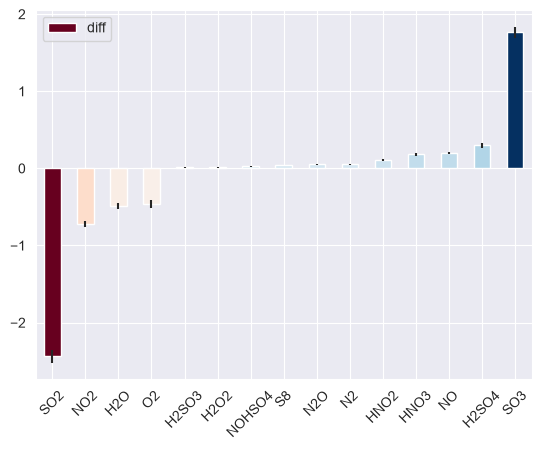

In [6]:
import seaborn as sns 
import matplotlib.pyplot as plt 
import matplotlib.colors as colors
sns.set_style('darkgrid')
sns.set_palette('pastel')


norm = colors.Normalize(
    vmin=average_data['diff'].min(), vmax=average_data['diff'].max()
    )
cmap = plt.get_cmap(name='RdBu')  # or any other colormap

bar_colors = [cmap(norm(value)) for value in average_data['diff']]

average_data.plot.bar(y='diff',yerr='sem',color=bar_colors,rot=45)

plt.show()

#### 5. generate a `pyvis` graph 

In [8]:
pyvis_kwargs = {'width':'100%',"height":"600px",'notebook':False,"font_color":'white','directed':True}
g = analysis.result_to_pyvis(data,head=10,**pyvis_kwargs)
g.save_graph(name="example_pyvis_graph.html")

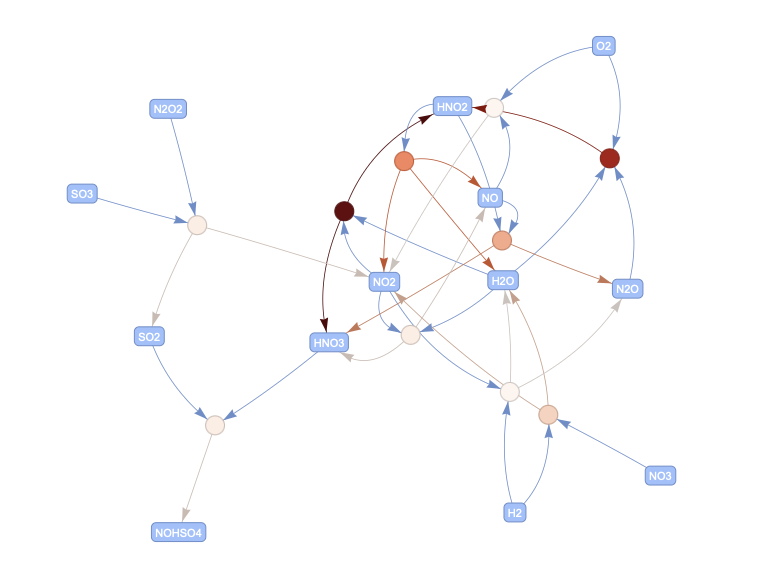

In [ ]:
! open example_pyvis_graph.html